## DPFSPDD with CONSTRAINT PROGRAMMING 
### CP-SAT OR-Tools
---
###### An application for solving the ***D***istributed ***P***ermutation ***F***low ***S***hop ***P***roblem with ***D***ue ***D***ates (DPFSPDD) using Google's ORTools CPSAT. Based on the mathematical model presented in the paper **"Effectively minimizing total tardiness in the Distributed Permutation Flow-shop Scheduling Problem using Constraint Programming"**.

---

##### 1. Load Problem Data / Initialization
##### 2. Display the Problem
##### 3. Call Solver
##### 4. Print Results
##### 5. Print Gantt Chart
##### 6. Print Sequence/Factory

***
> ### Load Problem Data / Initialization
> ###### We can choose the problem data from the Folder datasets/small OR datasets/large. After that, the data is placed in the corresponding variables.
> 

In [7]:
import os
from collections import defaultdict

filepath = "datasets/small/I_2_4_2_1.txt"
# filepath = "datasets/small/I_3_12_5_4.txt"
# filepath = "datasets/small/I_2_4_2_2.txt"
# filepath = "datasets/large/Ta003_4.txt"
ptime = {}
jobs_due_date = {}

problem_Category = os.path.basename(os.path.dirname(filepath))  # small
problem_id = os.path.splitext(os.path.basename(filepath))[0]  # I_2_4_2_1

with open(filepath, encoding="utf-8") as f:
        line1 = f.readline().strip().split()
        number_of_jobs, number_of_machines = int(line1[0]), int(line1[1])
        print("jobs, machines", number_of_jobs, number_of_machines)
        line2 = f.readline().strip()
        number_of_factories = int(line2)
        for j in range(number_of_jobs):
            line = f.readline().strip().split()
            ptime[j] = []
            for m in range(number_of_machines):
                ptime[j].append(int(line[2 * m + 1]))
        line3 = f.readline().strip()
        assert line3 == "Duedate"
        
        for j in range(number_of_jobs):
            jobs_due_date[j] = int(f.readline().strip())
print("PROCESSING TIMES: ",ptime, "JOBS: ",number_of_jobs, " - Due Dates :", jobs_due_date, " Number of Factories :", number_of_factories)            

permutation=True
verbose = True
time_limit = 30

J = len(ptime)
M = len(next(iter(ptime.values())))
F = number_of_factories
      
JOBS = range(J)
MACHINES = range(M)
FACTORIES = range(F)



jobs, machines 4 2
PROCESSING TIMES:  {0: [1, 4], 1: [86, 21], 2: [28, 67], 3: [32, 17]} JOBS:  4  - Due Dates : {0: 5, 1: 108, 2: 96, 3: 50}  Number of Factories : 2


***
> ### Display the Problem Data
> 

In [ ]:
#display the problem
for k, v in ptime.items():
    print(f"{k:3d}", end=": ")
    for x in v:
        print(f"{x:3d}", end="")
    print(f"| {jobs_due_date[k]:4d}")
print(f"problem={problem_id}, factories={number_of_factories}, jobs={number_of_jobs}, machines={number_of_machines}")

***
> ### RUN THE SOLVER
> ##### VARIABLES and CONSTRAINTS
>MODEL DESCRIPTION
>
$\text{Min} \sum_{j \in \mathbb{J}}{t_j}$ **(1)**

---

$\sum_{f \in \mathbb{F}}b_{jf}=1 \qquad \forall j \in \mathbb{J}$ **(2)**

---

$\text{no\_overlap}_{j \in \mathbb{J}}\text{(} x_{jf0} \text{)} \qquad \forall f \in \mathbb{F}$ **(3)**

---

$ o_{j_1j_2} \land b_{j_1f} \land b_{j_2f} \implies \text{end(} x_{j_1fm}\text{)} \leq \text{start(} x_{j_2fm} \text{)} \\
\lnot o_{j_1j_2} \land b_{j_1f} \land b_{j_2f} \implies \text{end(} x_{j_2fm}\text{)} \leq \text{start(} x_{j_1fm} \text{)}
\quad \forall j_1, j_2 \in \mathbb{J}: j_1 \le j_2,  \forall f \in \mathbb{F}, \forall m \in \mathbb{M} $  **(4)**

---

$b_{jf} \implies \text{end(} x_{jfm-1} \text{)} \leq \text{start(} x_{jfm} \text{)} \qquad \forall j \in \mathbb{J}, \forall f \in \mathbb{F}, \forall m \in \{1 \dots |\mathbb{M}|-1\}$ **(5)**

---

$t_{j} >= \text{end(}x_{jf|\mathbb{M}-1|}\text{)} - D_{j} \qquad \forall j \in \mathbb{J}, \forall f \in \mathbb{F}$ **(6)**

---



In [ ]:
import logging
from ortools.sat.python import cp_model
from itertools import combinations
import pandas as pd
from collections import defaultdict


logging.basicConfig(level=logging.DEBUG)
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

use_lexicographic_symmetry=False
use_min_index_symmetry=True


# Large upper bound for times
UB = sum(ptime[j][m] for j in JOBS for m in MACHINES) + 100
print("LARGER UPPER BOUND:", UB)
    
# VARIABLES
x       = defaultdict(cp_model.IntVar)  # interval variables for each job, factory, machine
b       = defaultdict(cp_model.IntVar)  # boolean variables for each job, factory `b[j, f] = 1` if job j is assigned to factory f
start   = defaultdict(cp_model.IntVar)  # start time of job j on machine m
end     = defaultdict(cp_model.IntVar)  # end time of job j on machine m
t       = defaultdict(cp_model.IntVar)  # integer variables measuring the tardiness of each job
    

model = cp_model.CpModel()

# VARIABLES
# assignment b[j,f] : job j assigned to factory f
for j in JOBS:
    for f in FACTORIES:
        b[j, f] = model.NewBoolVar(f"b_{j}_{f}")

# interval variables: for each job j, factory f, machine m:
# create start_j_f_m (IntVar), end_j_f_m (IntVar) and optional interval x_j_f_m
for j in JOBS:
    t[j] = model.new_int_var(0, UB, name=f"t_{j}")
    for f in FACTORIES:
        for m in MACHINES:
            # CP-SAT => NewIntVar(lb, ub, name)
            s = model.NewIntVar(0, UB, f"start_{j}_{f}_{m}")
            e = model.NewIntVar(0, UB, f"end_{j}_{f}_{m}")
            p = ptime[j][m]

            x[j, f, m] = model.NewOptionalIntervalVar(s, p, e, b[j, f], f"x_{j}_{f}_{m}")
            start[j, f, m] = s
            end[j, f, m] = e
                    
# order variables o[j1,j2,f] d
o = {}
if permutation:
    for j1, j2 in combinations(JOBS, 2):
        for f in FACTORIES:
            o[j1, j2, f] = model.NewBoolVar(f"o_{j1}_{j2}_{f}") #oj1,j2,f​=1⇒end(xj1,f,m​)≤start(xj2,f,m​)
            o[j2, j1, f] = model.NewBoolVar(f"o_{j2}_{j1}_{f}") #oj2,j1,f​=1⇒end(xj2,f,m​)≤start(xj1,f,m​)​
# =======================================================================================================

# CONSTRAINTS
# MODEL EQUATION (2) -  Each job assigned to exactly one factory
for j in JOBS:
    model.Add(sum(b[j, f] for f in FACTORIES) == 1)

# MODEL EQUATION (3) - No-overlap at first machine for each factory (global no-overlap)
for f in FACTORIES:
    model.AddNoOverlap([x[j, f, 0] for j in JOBS])

# MODEL EQUATION (4) order between pairs of jobs if they are in same factory
if permutation:
    # Use o variables to impose a consistent order across all machines
    for j1, j2 in combinations(JOBS, 2):
        for f in FACTORIES:
            # If both present and o[j1,j2,f]==1 => j1 before j2 on machine 0 (and we will propagate to all machines)
            model.Add(end[j1, f, 0] <= start[j2, f, 0]).OnlyEnforceIf([o[j1, j2, f], b[j1, f], b[j2, f]])
            model.Add(end[j2, f, 0] <= start[j1, f, 0]).OnlyEnforceIf([o[j2, j1, f], b[j1, f], b[j2, f]])
            # If either job not present then ordering variable is irrelevant:
            model.AddBoolOr([o[j1, j2, f], o[j2, j1, f], b[j1, f].Not(), b[j2, f].Not()])
    for f in FACTORIES:
        for m in range(1, M):
            for j1, j2 in combinations(JOBS, 2):
                model.Add(end[j1, f, m] <= start[j2, f, m]).OnlyEnforceIf([o[j1, j2, f], b[j1, f], b[j2, f]])
                model.Add(end[j2, f, m] <= start[j1, f, m]).OnlyEnforceIf([o[j2, j1, f], b[j1, f], b[j2, f]])
else:
    # Ensure no overlap for machines 1..M-1
    for f in FACTORIES:
        for m in range(1, M):
            model.AddNoOverlap([x[j, f, m] for j in JOBS])

# MODEL EQUATION (5) for each job in each factory, machine m starts after previous end
for j in JOBS:
    for f in FACTORIES:
        for m in range(1, M):
           model.Add(end[j, f, m - 1] <= start[j, f, m]).OnlyEnforceIf(b[j, f])

# MODEL EQUATION (6) tardiness definition
for j in JOBS:
    Dj = jobs_due_date[j]
    for f in FACTORIES:
        model.Add(t[j] >= end[j, f, M - 1] - Dj).OnlyEnforceIf(b[j, f])
  
# # Symmetry breaking (7): b_0,0 = 1 (first job assigned to first factory)
# model.Add(b[0, 0] == 1)

# #Symmetry breaking (8): binary-weight lexicographic ordering of factories
# if use_lexicographic_symmetry and F > 1:
#     powers = [2 ** j for j in JOBS]
#     for f in range(F - 1):
#        lhs = sum(powers[j] * b[j, f] for j in JOBS)
#        rhs = sum(powers[j] * b[j, f + 1] for j in JOBS)
#        model.Add(lhs <= rhs)

# # Symmetry breaking (9)-(10): min-index y_f variables
# if use_min_index_symmetry and y is not None and F > 2:
#     #y[f] <= j for every job j present at factory f (so y[f] becomes min index)
#     for f in range(1, F):
#         for j in JOBS:
#             # if b[j,f] then y[f] <= j
#             model.Add(y[f] <= j).OnlyEnforceIf(b[j, f])
#     # enforce increasing y[f]
#     for f in range(1, F - 1):
#         model.Add(y[f] < y[f + 1])


# OBJECTIVE: minimize total tardiness Equation (1)
obj = model.NewIntVar(0, UB * J, "obj")
model.Add(obj == sum(t[j] for j in JOBS))
model.Minimize(obj)

if verbose:
    logging.info(model.ModelStats())

print(model.model_stats())
# SOLVE
solver = cp_model.CpSolver()
solver.parameters.max_time_in_seconds = time_limit
solver.parameters.num_search_workers = 6
solver.parameters.log_search_progress = False
    
status = solver.Solve(model)
if status not in (cp_model.OPTIMAL, cp_model.FEASIBLE):
    raise RuntimeError("No solution found")

schedule = { (j,f,m): None for j in JOBS for f in FACTORIES for m in MACHINES }
assignment = { j: None for j in JOBS }
for j in JOBS:
    for f in FACTORIES:
        if solver.Value(b[j, f]) == 1:
            assignment[j] = f
            for m in MACHINES:
                schedule[j, f, m] = solver.Value(start[j, f, m])
                # DEL sol.schedule(j, f, m, solver.value(start[j, f, m]))
result = {
    "status": "OPTIMAL" if status == cp_model.OPTIMAL else "FEASIBLE",
    "objective": solver.ObjectiveValue(),
    "assignment": assignment,
    "start_times": schedule,
    "tardiness": { j: solver.Value(t[j]) for j in JOBS },
    "best_bound": solver.BestObjectiveBound(),
}
print("Objective value:", solver.objective_value)
print("Objective Best Bound:", solver.best_objective_bound)


INFO:root:optimization model '': (model_fingerprint: 0xd167123c2b0003a3)
#Variables: 69 (#ints: 1 in objective) (64 primary variables)
  - 32 Booleans in [0,1]
  - 36 in [0,356]
  - 1 in [0,1424]
#kBoolOr: 12 (#literals: 48)
#kInterval: 16 (#enforced: 16)
#kLinear2: 68 (#enforced: 64 #multi: 48)
#kLinearN: 1 (#terms: 5)
#kNoOverlap: 2 (#intervals: 8, #optional: 8)


LARGER UPPER BOUND: 356
optimization model '': (model_fingerprint: 0xd167123c2b0003a3)
#Variables: 69 (#ints: 1 in objective) (64 primary variables)
  - 32 Booleans in [0,1]
  - 36 in [0,356]
  - 1 in [0,1424]
#kBoolOr: 12 (#literals: 48)
#kInterval: 16 (#enforced: 16)
#kLinear2: 68 (#enforced: 64 #multi: 48)
#kLinearN: 1 (#terms: 5)
#kNoOverlap: 2 (#intervals: 8, #optional: 8)
Objective value: 27.0
Objective Best Bound: 27.0


***
> ### Print the Solver Results
> 

In [19]:
              
summary = {
    "Solver Status": result["status"],
    "Objective (Total Tardiness)": result["objective"],
    "Best Bound": result["best_bound"],
    "Optimality Gap (%)": round(100 * (result["objective"] - result["best_bound"]) / result["objective"], 2)
    }
       
jobs_df = pd.DataFrame([
    {
    "Job": j,
    "Due Date": jobs_due_date[j],
    "Assigned Factory": result["assignment"][j],
    "Finished Time": result["start_times"][j,result["assignment"][j],M-1] + ptime[j][M-1],
    "Tardiness": result["tardiness"][j]
    }
    for j in result["assignment"]
    ])

FACTORIES = sorted({f for (_, f, _) in result["start_times"].keys()})
       
print(pd.DataFrame([summary]))                              #print SUMMARY
print(jobs_df)                                              #print jobs Assignments


     


  Solver Status  Objective (Total Tardiness)  Best Bound  Optimality Gap (%)
0       OPTIMAL                         27.0        27.0                 0.0
   Job  Due Date  Assigned Factory  Finished Time  Tardiness
0    0         5                 1              5          0
1    1       108                 0            135         27
2    2        96                 0             95          0
3    3        50                 1             50          0


***
> ### Print the Gantt Chart
> 

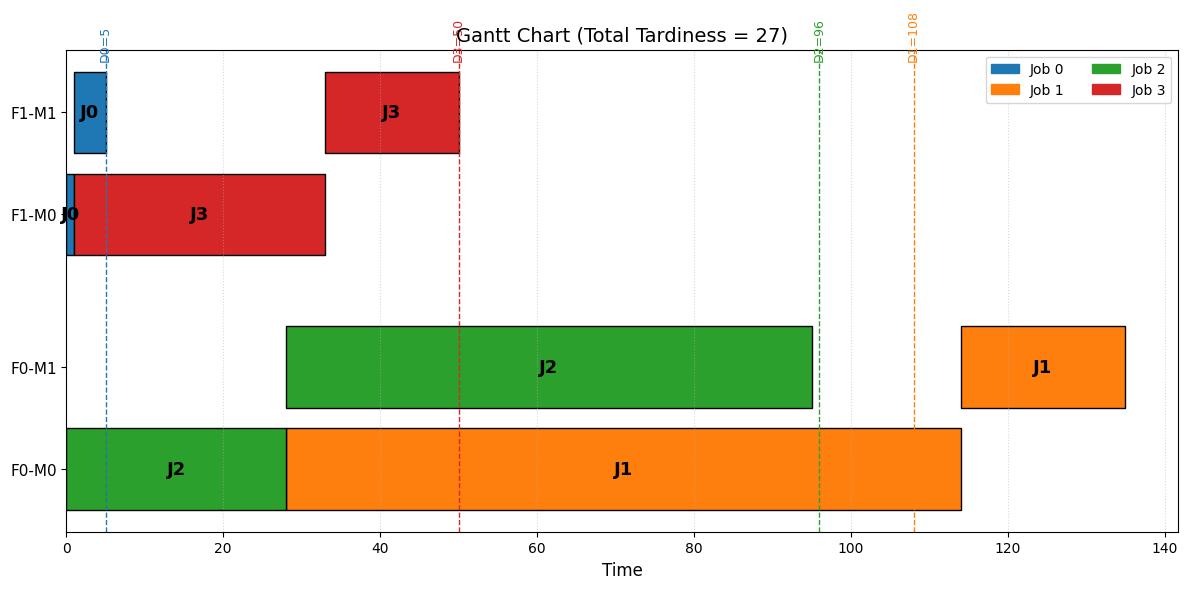

In [20]:
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Collect all the keys from result
FACTORIES = sorted({f for (_, f, _) in result["start_times"].keys()})
MACHINES = sorted({m for (_, _, m) in result["start_times"].keys()})
JOBS = sorted(ptime.keys())

# --- Colormap ---
colors = plt.colormaps.get_cmap("tab10")

fig, ax = plt.subplots(figsize=(12, 6))

yticks, ylabels = [], []
bar_height = 0.8          # increased from 0.35
label_fontsize = 13       # increased text size

for f in FACTORIES:
    for m in MACHINES:
        y = f * (len(MACHINES) + 0.5) + m
        yticks.append(y)
        ylabels.append(f"F{f}-M{m}")

        for (j, ff, mm), start in result["start_times"].items():
            if f == ff and m == mm and start is not None:
                dur = ptime[j][m]
                if dur is None or isinstance(dur, str):
                    continue

                ax.barh(
                    y,
                    dur,
                    left=start,
                    height=bar_height,
                    color=colors(j % len(JOBS)),
                    edgecolor="black",
                    align="center"
                )

                ax.text(
                    start + dur / 2,
                    y,
                    f"J{j}",
                    va="center",
                    ha="center",
                    fontsize=label_fontsize,
                    color="black",
                    fontweight="bold"
                )

# --- Due Dates ---
for j in JOBS:
    Dj = jobs_due_date[j]
    ax.axvline(Dj, color=colors(j % len(JOBS)), linestyle="--", linewidth=1)
    ax.text(
        Dj,
        max(yticks) + 0.5,
        f"D{j}={Dj}",
        rotation=90,
        va="bottom",
        ha="center",
        fontsize=9,
        color=colors(j % len(JOBS))
    )

ax.set_yticks(yticks)
ax.set_yticklabels(ylabels, fontsize=11)
ax.set_xlabel("Time", fontsize=12)
ax.set_title(f"Gantt Chart (Total Tardiness = {result.get('objective', 0):.0f})", fontsize=14)

ax.grid(True, axis="x", linestyle=":", alpha=0.5)

# --- Legend ---
patches = [mpatches.Patch(color=colors(j % len(JOBS)), label=f"Job {j}") for j in JOBS]
ax.legend(handles=patches, loc="upper right", fontsize=10, ncol=2)

plt.tight_layout()
plt.show()

***
> ### Print the SEQUENCE / FACTORY


In [ ]:
raw = result.get("start_times", {})
flat = {}
if all(isinstance(k, tuple) and len(k) == 3 for k in raw.keys()):
    flat = dict(raw)
else:
    for j, v1 in raw.items():
        if isinstance(v1, dict):
            for f, v2 in v1.items():
                if isinstance(v2, dict):
                    for m, st in v2.items():
                        flat[(int(j), int(f), int(m))] = st
                else:
                    flat[(int(j), int(f), 0)] = v2
        else:
            pass

factories = sorted({f for (_, f, _) in flat.keys()})
jobs = sorted({j for (j, _, _) in flat.keys()})
j_f_start = {}
for (j, f, m), st in flat.items():
    j_f_start.setdefault((j, f), []).append((m, st))

j_f_best_start = {}
for (j, f), lst in j_f_start.items():
    m0_entries = [st for (m, st) in lst if m == 0 and st is not None]
    if m0_entries:
        j_f_best_start[(j, f)] = m0_entries[0]
    else:
        numeric = [st for (m, st) in lst if st is not None]
        j_f_best_start[(j, f)] = min(numeric) if numeric else None

factory_sequences = {}
for f in factories:
    entries = []
    for j in jobs:
        start = j_f_best_start.get((j, f), None)
        if start is not None:
            entries.append((j, float(start)))
    entries.sort(key=lambda x: (x[1], x[0]))
    factory_sequences[f] = [j for j, _ in entries]
print("SEQUENCE/FACTORY :",factory_sequences)      




***